# STAT 4970W: Data Ethics Assignment
### Good vs. Bad Prompting with AI

**Name:** YOUR_NAME
**Date:** TODAY'S_DATE

---

## Overview

In this assignment, you will practice interacting with an AI assistant (such as ChatGPT or Claude) to work through a logistic regression analysis on a real dataset. The main learning goal is not just the statistics, it's learning how to write effective, specific prompts that get you useful statistical output and interpretation, versus vague prompts that give you generic or incorrect answers.

You will:
1. Run a logistic regression analysis in Python
2. Use AI to help you interpret outputs: first with a **bad prompt**, then with a **good prompt**
3. Compare what you got and reflect on the difference
4. Document all your AI interactions in a `README.md` file (see instructions below)

---

## README Documentation Requirement

> **This is required for full credit.**
>
> As you work through this notebook, you must document every prompt you send to an AI tool in a file called `README.md`. For **each prompt**, include:
> - A **screenshot** of the prompt you typed and the response you received
> - A label indicating whether it was a **Bad Prompt** or **Good Prompt**
> - A 1–2 sentence note on what was useful or lacking in the response
>
> Submit your `README.md` alongside this notebook.

---

## Dataset

We will use the **`titanic`** dataset, which contains passenger information from the Titanic and whether they survived. Your goal is to model the **probability of survival** using logistic regression.

Key variables:
- `Survived` — 0 = did not survive, 1 = survived *(response variable)*
- `Pclass` — ticket class (1st, 2nd, 3rd)
- `Sex` — male or female
- `Age` — age in years
- `Fare` — ticket fare paid
- `SibSp` — number of siblings/spouses aboard
- `Parch` — number of parents/children aboard

---
## Part 0: Setup

Run the cell below to load all required libraries and the dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Load Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Part 1: Exploratory Data Analysis (EDA)

Before building a model, we need to understand our data.

**Your task:** Run the cells below and answer the reflection questions.

In [3]:
# --- 1a. Check for missing values and basic info ---
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Summary Statistics ===")
df.describe()

=== Missing Values ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== Summary Statistics ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


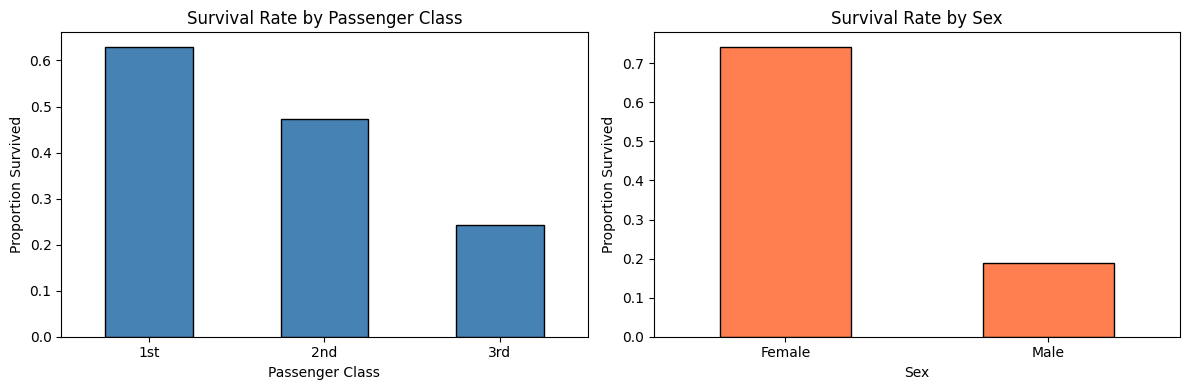

In [4]:
# --- 1b. Survival rate by class and sex ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival by Pclass
df.groupby('Pclass')['Survived'].mean().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Survival Rate by Passenger Class')
axes[0].set_ylabel('Proportion Survived')
axes[0].set_xlabel('Passenger Class')
axes[0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)

# Survival by Sex
df.groupby('Sex')['Survived'].mean().plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Survival Rate by Sex')
axes[1].set_ylabel('Proportion Survived')
axes[1].set_xlabel('Sex')
axes[1].set_xticklabels(['Female', 'Male'], rotation=0)

plt.tight_layout()
plt.show()

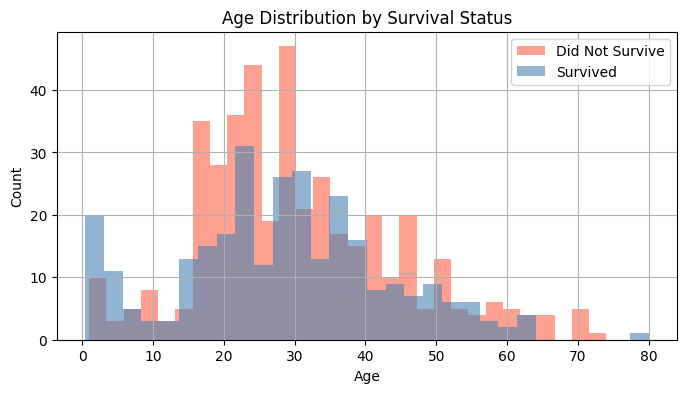

In [5]:
# --- 1c. Age distribution by survival ---
plt.figure(figsize=(8, 4))
df[df['Survived'] == 0]['Age'].dropna().hist(alpha=0.6, label='Did Not Survive', bins=30, color='tomato')
df[df['Survived'] == 1]['Age'].dropna().hist(alpha=0.6, label='Survived', bins=30, color='steelblue')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival Status')
plt.legend()
plt.show()

### Reflection 1.1

Based on the EDA plots above, which variables appear most strongly associated with survival? Why?

> **Your answer here:**

---
## Part 2: Data Preprocessing

We need to handle missing values and encode categorical variables before fitting the model.

In [6]:
# --- 2a. Handle missing values and encode categoricals ---
df_model = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']].copy()

# Fill missing Age with median
df_model['Age'] = df_model['Age'].fillna(df_model['Age'].median())

# Encode Sex as binary
df_model['Sex'] = (df_model['Sex'] == 'female').astype(int)  # 1 = female, 0 = male

print("Cleaned dataset shape:", df_model.shape)
print("Remaining missing values:", df_model.isnull().sum().sum())
df_model.head()

Cleaned dataset shape: (891, 7)
Remaining missing values: 0


,Survived,Pclass,Sex,Age,Fare,SibSp,Parch
0,0,3,0,22.0,7.2500,1,0
1,1,1,1,38.0,71.2833,1,0
2,1,3,1,26.0,7.9250,0,0
3,1,1,1,35.0,53.1000,1,0
4,0,3,0,35.0,8.0500,0,0


In [7]:
# --- 2b. Check class balance ---
survived_counts = df_model['Survived'].value_counts()
print("Survival counts:")
print(survived_counts)
print(f"\nClass balance: {survived_counts[0]/len(df_model)*100:.1f}% not survived, "
      f"{survived_counts[1]/len(df_model)*100:.1f}% survived")

Survival counts:
Survived
0    549
1    342
Name: count, dtype: int64

Class balance: 61.6% not survived, 38.4% survived


---
## Part 3: Fitting the Logistic Regression Model

We will use `statsmodels` to fit the model, which gives us coefficient estimates, p-values, and confidence intervals — just like the output you'd see in R.

In [8]:
# --- 3a. Fit logistic regression with statsmodels ---
X = df_model[['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']]
y = df_model['Survived']

# Add intercept
X_const = sm.add_constant(X)

# Fit model
logit_model = sm.Logit(y, X_const)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.442861
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  891
Model:                          Logit   Df Residuals:                      884
Method:                           MLE   Df Model:                            6
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.3350
Time:                        21:10:26   Log-Likelihood:                -394.59
converged:                       True   LL-Null:                       -593.33
Covariance Type:            nonrobust   LLR p-value:                 9.750e-83
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.1802      0.479      4.551      0.000       1.241       3.119
Pclass        -1.0874      0.

In [9]:
# --- 3b. Compute and display odds ratios ---
odds_ratios = pd.DataFrame({
    'Odds Ratio': np.exp(result.params),
    'Lower 95% CI': np.exp(result.conf_int()[0]),
    'Upper 95% CI': np.exp(result.conf_int()[1]),
    'p-value': result.pvalues
})

odds_ratios = odds_ratios.drop('const').round(4)
print("=== Odds Ratios ===")
print(odds_ratios)

=== Odds Ratios ===
        Odds Ratio  Lower 95% CI  Upper 95% CI  p-value
Pclass      0.3371        0.2565        0.4430   0.0000
Sex        15.8137       10.7107       23.3478   0.0000
Age         0.9614        0.9468        0.9762   0.0000
Fare        1.0028        0.9982        1.0075   0.2276
SibSp       0.7055        0.5698        0.8736   0.0014
Parch       0.8988        0.7143        1.1309   0.3627


---
## Part 4: The Core Exercise: Bad Prompt vs. Good Prompt

This is the heart of the assignment. You will interact with an AI tool **twice** for interpreting the logistic regression output above.

> **Before you start:** Copy the summary table from Part 3 output. You will paste it into your prompts.

---

### Step 4A — Write a BAD Prompt

A bad prompt is **vague**, gives the AI no context, and asks a question that could mean anything.

**Example of a bad prompt:**  
> *"What do these numbers mean?"*

**Your task:** Go to your AI tool (of your choice) and send a similarly vague prompt about the model output. Paste the response below.

#### Bad Prompt — What You Sent:

> *(Write the exact prompt you sent here)*

#### AI Response Summary:

> *(Summarize or paste the key parts of what the AI said)*

#### Reflection 4A:

What was missing or unhelpful in this response? Was the AI able to interpret your specific model correctly?

> **Your answer here:**

---

### Step 4B — Write a GOOD Prompt

A good prompt:
- Gives the AI **context** (what dataset, what method, what predictors)
- States your **specific question** clearly
- Includes relevant **output or numbers** the AI needs
- Specifies the **format** or detail level you want

**Example of a good prompt:**  
> *"I fit a logistic regression model in Python using statsmodels to predict Titanic survival (1 = survived, 0 = not). My predictors are Pclass, Sex (1=female), Age, Fare, SibSp, and Parch. Here is my odds ratio table: [paste table]. Can you interpret the odds ratio for Sex and Pclass in plain English, and tell me whether those predictors are statistically significant at the 0.05 level?"*

**Your task:** Send a well-crafted prompt to the AI: include your actual odds ratio table from Part 3b.

#### Good Prompt — What You Sent:

> *(Write the exact prompt you sent here: it should be longer and more specific than the bad prompt)*

#### AI Response Summary:

> *(Summarize or paste the key parts of what the AI said)*

#### Reflection 4B:

How was this response different from the bad prompt response? Was the AI able to give a correct, specific interpretation? What made your prompt work better?

> **Your answer here:**

---
## Part 5: Model Assessment

Now let's evaluate how well the model actually performs.

=== Classification Report ===
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.85      0.84       549
       Survived       0.74      0.71      0.73       342

       accuracy                           0.79       891
      macro avg       0.78      0.78      0.78       891
   weighted avg       0.79      0.79      0.79       891

=== Confusion Matrix ===


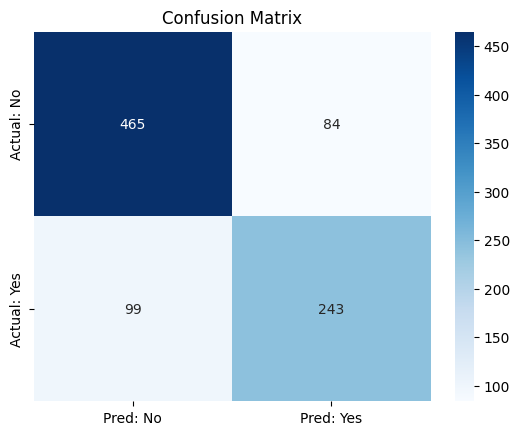

In [10]:
# --- 5a. Classification metrics ---
y_pred_proba = result.predict(X_const)
y_pred = (y_pred_proba >= 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(y, y_pred, target_names=['Did Not Survive', 'Survived']))

print("=== Confusion Matrix ===")
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])
plt.title('Confusion Matrix')
plt.show()

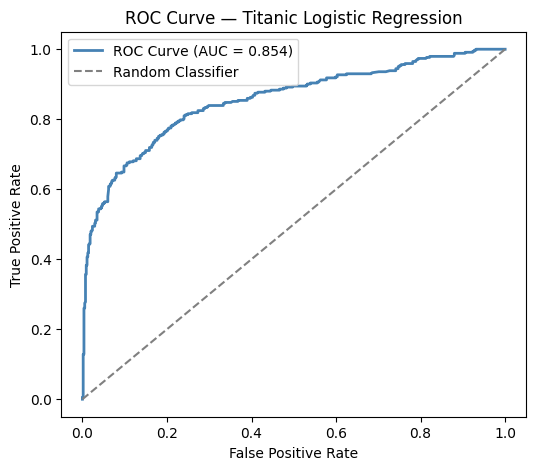

AUC: 0.8544


In [11]:
# --- 5b. ROC Curve and AUC ---
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
auc = roc_auc_score(y, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Titanic Logistic Regression')
plt.legend()
plt.show()

print(f"AUC: {auc:.4f}")

### Reflection 5.1

What does the AUC value tell you about the model's discriminatory ability? How does it compare to a random classifier?

> **Your answer here:**